# 案例1：Malthus人口增长模型 - 美国早期人口分析
# 目标：使用Malthus指数增长模型分析美国1790-1860年人口数据

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')
# 设置中文字体（如果需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
print("=" * 60)
print("案例1：Malthus人口增长模型 - 美国早期人口分析")
print("=" * 60)

案例1：Malthus人口增长模型 - 美国早期人口分析


# 1. 数据准备

In [3]:
print("\n1. 历史数据准备")
print("-" * 30)

# 美国1790-1860年人口数据（单位：百万）
years = np.array([1790, 1800, 1810, 1820, 1830, 1840, 1850, 1860])
population = np.array([3.9, 5.3, 7.2, 9.6, 12.9, 17.1, 23.2, 31.4])

# 创建DataFrame便于分析
data = pd.DataFrame({
    'Year': years,
    'Population': population,
    'Time': years - 1790  # 以1790年为起点
})

print("美国早期人口数据：")
print(data)


1. 历史数据准备
------------------------------
美国早期人口数据：
   Year  Population  Time
0  1790         3.9     0
1  1800         5.3    10
2  1810         7.2    20
3  1820         9.6    30
4  1830        12.9    40
5  1840        17.1    50
6  1850        23.2    60
7  1860        31.4    70


In [4]:
# 2. Malthus模型理论回顾
print("\n2. Malthus模型理论")
print("-" * 30)
print("微分方程：dN/dt = rN")
print("解析解：N(t) = N₀ × e^(rt)")
print("线性化：ln(N) = ln(N₀) + rt")
print("参数：N₀ = 初始人口，r = 内在增长率")


2. Malthus模型理论
------------------------------
微分方程：dN/dt = rN
解析解：N(t) = N₀ × e^(rt)
线性化：ln(N) = ln(N₀) + rt
参数：N₀ = 初始人口，r = 内在增长率


In [5]:
# 3. 数据预处理
print("\n3. 数据线性化处理")
print("-" * 30)

t = data['Time'].values  # 时间数组
N = data['Population'].values  # 人口数组
ln_N = np.log(N)  # 对人口取对数

# 添加线性化数据到DataFrame
data['ln_Population'] = ln_N

print("线性化后的数据：")
for i in range(len(data)):
    print(f"t={data.iloc[i]['Time']:2f}, N={data.iloc[i]['Population']:4.1f}, ln(N)={data.iloc[i]['ln_Population']:.3f}")


3. 数据线性化处理
------------------------------
线性化后的数据：
t=0.000000, N= 3.9, ln(N)=1.361
t=10.000000, N= 5.3, ln(N)=1.668
t=20.000000, N= 7.2, ln(N)=1.974
t=30.000000, N= 9.6, ln(N)=2.262
t=40.000000, N=12.9, ln(N)=2.557
t=50.000000, N=17.1, ln(N)=2.839
t=60.000000, N=23.2, ln(N)=3.144
t=70.000000, N=31.4, ln(N)=3.447


In [6]:
# 4. 参数估计 - 方法一：使用numpy.polyfit
print("\n4. 参数估计 - 线性回归方法")
print("-" * 30)

# 线性回归：ln(N) = ln(N₀) + rt
coefficients = np.polyfit(t, ln_N, 1)
r_estimated = coefficients[0]  # 斜率 = 增长率r
ln_N0_estimated = coefficients[1]  # 截距 = ln(N₀)
N0_estimated = np.exp(ln_N0_estimated)  # 初始人口N₀

print(f"估计的增长率 r = {r_estimated:.6f} /年")
print(f"估计的初始人口 N₀ = {N0_estimated:.2f} 百万")
print(f"年增长率 = {r_estimated*100:.2f}%")
print(f"倍增时间 = {np.log(2)/r_estimated:.1f} 年")


4. 参数估计 - 线性回归方法
------------------------------
估计的增长率 r = 0.029611 /年
估计的初始人口 N₀ = 3.94 百万
年增长率 = 2.96%
倍增时间 = 23.4 年


In [7]:
# 5. 参数估计 - 方法二：使用sklearn
print("\n5. 参数估计验证 - sklearn方法")
print("-" * 30)

# 使用sklearn的LinearRegression
from sklearn.linear_model import LinearRegression

# 重新整理数据格式
X = t.reshape(-1, 1)  # 时间作为特征
y = ln_N  # ln(人口)作为目标

# 建立线性回归模型
model = LinearRegression()
model.fit(X, y)

r_sklearn = model.coef_[0]
ln_N0_sklearn = model.intercept_
N0_sklearn = np.exp(ln_N0_sklearn)

print(f"sklearn验证 - 增长率 r = {r_sklearn:.6f} /年")
print(f"sklearn验证 - 初始人口 N₀ = {N0_sklearn:.2f} 百万")


5. 参数估计验证 - sklearn方法
------------------------------
sklearn验证 - 增长率 r = 0.029611 /年
sklearn验证 - 初始人口 N₀ = 3.94 百万


In [8]:
# 6. 模型预测
print("\n6. 模型预测与验证")
print("-" * 30)

# 定义Malthus模型函数
def malthus_model(t, N0, r):
    """
    Malthus人口增长模型
    参数：
    t: 时间
    N0: 初始人口
    r: 增长率
    """
    return N0 * np.exp(r * t)

# 对原始数据进行预测
t_fit = np.linspace(0, 70, 100)  # 0-70年的连续时间
N_fit = malthus_model(t_fit, N0_estimated, r_estimated)

# 计算拟合优度
N_predicted = malthus_model(t, N0_estimated, r_estimated)
r2 = r2_score(N, N_predicted)
rmse = np.sqrt(np.mean((N - N_predicted)**2))

print(f"拟合优度 R² = {r2:.4f}")
print(f"均方根误差 RMSE = {rmse:.2f} 百万")


6. 模型预测与验证
------------------------------
拟合优度 R² = 0.9999
均方根误差 RMSE = 0.09 百万


In [9]:
# 7. 历史验证 - 预测1870年人口
print("\n7. 历史验证 - 1870年人口预测")
print("-" * 30)

t_1870 = 1870 - 1790  # 1870年对应的时间
N_1870_predicted = malthus_model(t_1870, N0_estimated, r_estimated)
N_1870_actual = 38.6  # 1870年实际人口

print(f"预测1870年人口：{N_1870_predicted:.1f} 百万")
print(f"实际1870年人口：{N_1870_actual:.1f} 百万")
print(f"预测误差：{abs(N_1870_predicted - N_1870_actual)/N_1870_actual*100:.1f}%")


7. 历史验证 - 1870年人口预测
------------------------------
预测1870年人口：42.1 百万
实际1870年人口：38.6 百万
预测误差：9.0%


In [10]:
# 8. 长期预测的问题展示
print("\n8. 长期预测的局限性")
print("-" * 30)

# 预测2000年人口
t_2000 = 2000 - 1790
N_2000_predicted = malthus_model(t_2000, N0_estimated, r_estimated)
N_2000_actual = 282  # 2000年美国实际人口约282百万

print(f"预测2000年人口：{N_2000_predicted:.0f} 百万")
print(f"实际2000年人口：{N_2000_actual:.0f} 百万")
print(f"预测误差：{abs(N_2000_predicted - N_2000_actual)/N_2000_actual*100:.0f}%")
print("可见长期预测严重偏离实际！")


8. 长期预测的局限性
------------------------------
预测2000年人口：1975 百万
实际2000年人口：282 百万
预测误差：600%
可见长期预测严重偏离实际！



9. 结果可视化
------------------------------


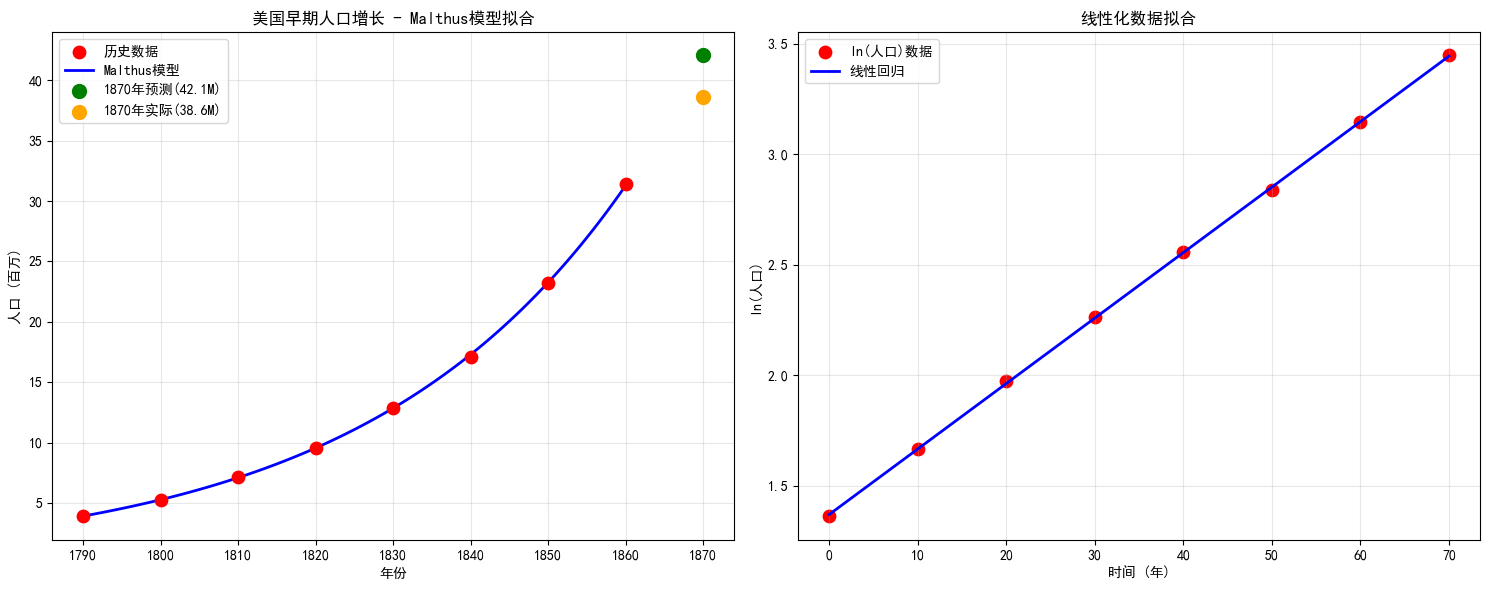


10. 残差分析
------------------------------
残差统计：
残差均值：-0.002
残差标准差：0.093
最大绝对残差：0.199


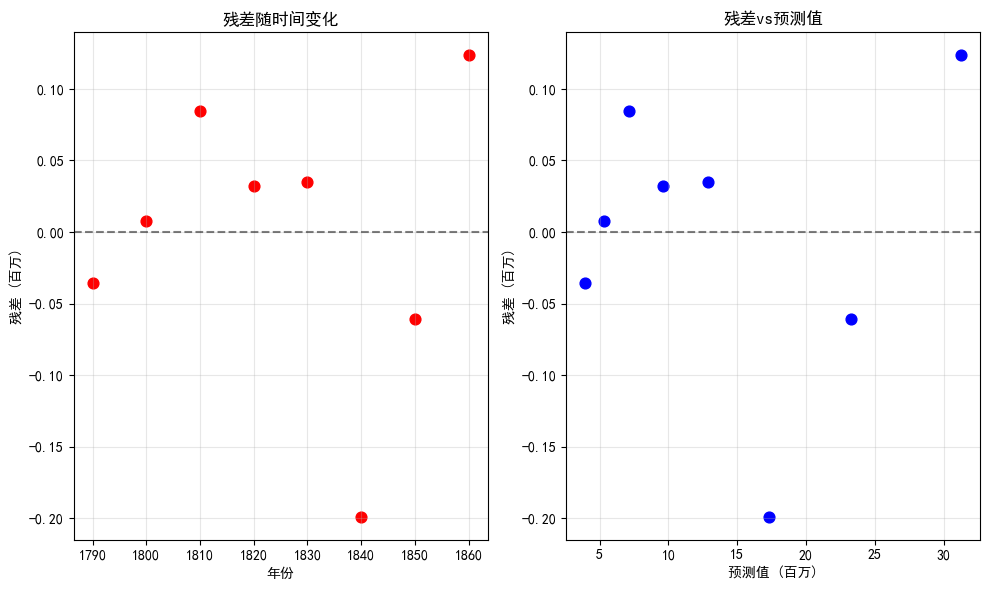

In [11]:
# 9. 数据可视化
print("\n9. 结果可视化")
print("-" * 30)

# 创建图形
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 子图1：原始数据和模型拟合
ax1.scatter(years, population, color='red', s=80, label='历史数据', zorder=5)
ax1.plot(years[0] + t_fit, N_fit, 'b-', linewidth=2, label='Malthus模型')
ax1.set_xlabel('年份')
ax1.set_ylabel('人口 (百万)')
ax1.set_title('美国早期人口增长 - Malthus模型拟合')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 添加预测点
ax1.scatter([1870], [N_1870_predicted], color='green', s=100, 
           label=f'1870年预测({N_1870_predicted:.1f}M)', zorder=5)
ax1.scatter([1870], [N_1870_actual], color='orange', s=100, 
           label=f'1870年实际({N_1870_actual:.1f}M)', zorder=5)
ax1.legend()

# 子图2：线性化数据和回归直线
ax2.scatter(t, ln_N, color='red', s=80, label='ln(人口)数据')
ln_N_fit = ln_N0_estimated + r_estimated * t
ax2.plot(t, ln_N_fit, 'b-', linewidth=2, label='线性回归')
ax2.set_xlabel('时间 (年)')
ax2.set_ylabel('ln(人口)')
ax2.set_title('线性化数据拟合')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 10. 残差分析
print("\n10. 残差分析")
print("-" * 30)

residuals = N - N_predicted
print("残差统计：")
print(f"残差均值：{np.mean(residuals):.3f}")
print(f"残差标准差：{np.std(residuals):.3f}")
print(f"最大绝对残差：{np.max(np.abs(residuals)):.3f}")

# 绘制残差图
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.scatter(years, residuals, color='red', s=60)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('年份')
plt.ylabel('残差 (百万)')
plt.title('残差随时间变化')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(N_predicted, residuals, color='blue', s=60)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('预测值 (百万)')
plt.ylabel('残差 (百万)')
plt.title('残差vs预测值')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




11. 参数敏感性分析
------------------------------


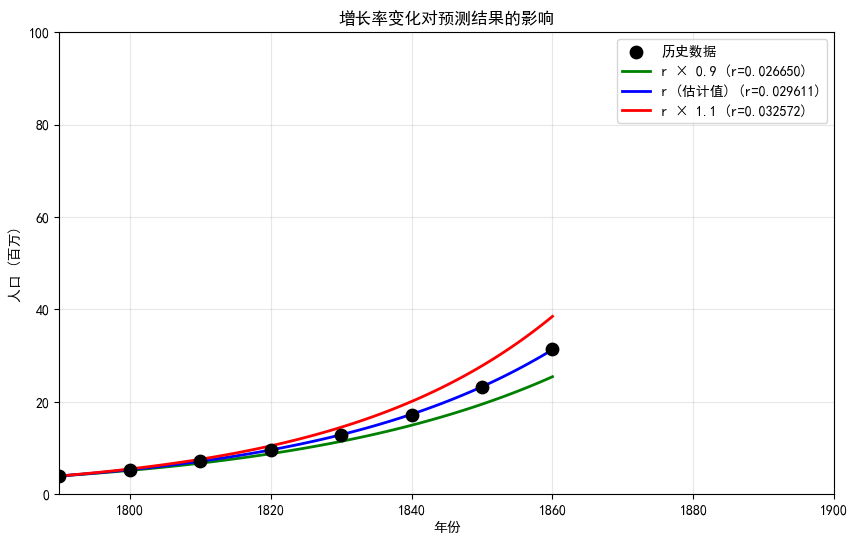

In [12]:
# 11. 敏感性分析
print("\n11. 参数敏感性分析")
print("-" * 30)

# 分析增长率r变化对预测的影响
r_variations = [r_estimated * 0.9, r_estimated, r_estimated * 1.1]
labels = ['r × 0.9', 'r (估计值)', 'r × 1.1']
colors = ['green', 'blue', 'red']

plt.figure(figsize=(10, 6))
plt.scatter(years, population, color='black', s=80, label='历史数据', zorder=5)

for i, r_var in enumerate(r_variations):
    N_var = malthus_model(t_fit, N0_estimated, r_var)
    plt.plot(years[0] + t_fit, N_var, color=colors[i], 
             linewidth=2, label=f'{labels[i]} (r={r_var:.6f})')

plt.xlabel('年份')
plt.ylabel('人口 (百万)')
plt.title('增长率变化对预测结果的影响')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(1790, 1900)
plt.ylim(0, 100)
plt.show()



In [13]:
# 12. 总结和思考题
print("\n12. 案例1总结")
print("=" * 60)
print(f"✓ 成功拟合了美国1790-1860年人口数据")
print(f"✓ 估计增长率：{r_estimated*100:.2f}%/年")
print(f"✓ 倍增时间：{np.log(2)/r_estimated:.1f}年")
print(f"✓ 短期预测精度：{(1-abs(N_1870_predicted - N_1870_actual)/N_1870_actual)*100:.1f}%")
print(f"✗ 长期预测偏差：{abs(N_2000_predicted - N_2000_actual)/N_2000_actual*100:.0f}%")

print("\n思考题：")
print("1. 为什么Malthus模型在短期内预测准确，但长期预测失效？")
print("2. 在什么情况下，指数增长模型仍然适用？")
print("3. 如果我们有更多的历史数据，估计的参数会更准确吗？")

# 13. 练习任务
print("\n13. 练习任务")
print("-" * 30)
print("请尝试以下练习：")
print("1. 修改代码，分析其他时间段的数据（如1790-1840年）")
print("2. 计算不同时间段的增长率，观察变化趋势")
print("3. 尝试预测1880年、1900年的人口，并分析误差变化")

# 14. 扩展数据分析
print("\n14. 扩展分析：不同时间段的增长率")
print("-" * 30)

# 分析不同时间段的增长率变化
periods = [(0, 4), (4, 8), (0, 6)]  # 不同时间段的索引
period_names = ['1790-1830', '1830-1860', '1790-1850']

for i, (start, end) in enumerate(periods):
    t_period = t[start:end]
    ln_N_period = ln_N[start:end]
    
    # 线性回归
    coeffs = np.polyfit(t_period, ln_N_period, 1)
    r_period = coeffs[0]
    
    print(f"{period_names[i]}年增长率：{r_period*100:.2f}%/年")

print("\n观察：增长率是否在不同时期保持稳定？这对模型假设意味着什么？")




12. 案例1总结
✓ 成功拟合了美国1790-1860年人口数据
✓ 估计增长率：2.96%/年
✓ 倍增时间：23.4年
✓ 短期预测精度：91.0%
✗ 长期预测偏差：600%

思考题：
1. 为什么Malthus模型在短期内预测准确，但长期预测失效？
2. 在什么情况下，指数增长模型仍然适用？
3. 如果我们有更多的历史数据，估计的参数会更准确吗？

13. 练习任务
------------------------------
请尝试以下练习：
1. 修改代码，分析其他时间段的数据（如1790-1840年）
2. 计算不同时间段的增长率，观察变化趋势
3. 尝试预测1880年、1900年的人口，并分析误差变化

14. 扩展分析：不同时间段的增长率
------------------------------
1790-1830年增长率：3.01%/年
1830-1860年增长率：2.97%/年
1790-1850年增长率：2.96%/年

观察：增长率是否在不同时期保持稳定？这对模型假设意味着什么？

15. 代码函数封装
------------------------------
封装函数测试结果：
growth_rate: 0.0296
initial_population: 3.9357
r_squared: 0.9999
rmse: 0.0930
doubling_time: 23.4082

案例1完成！请继续学习案例2：Logistic模型


In [ ]:
# 15. 函数封装（供学生练习使用）
print("\n15. 代码函数封装")
print("-" * 30)
years = np.array([1790, 1800, 1810, 1820, 1830, 1840, 1850, 1860])
population = np.array([3.9, 5.3, 7.2, 9.6, 12.9, 17.1, 23.2, 31.4])
def fit_malthus_model(years, population):
    """
    拟合Malthus人口增长模型
    
    参数：
    years: 年份数组
    population: 人口数组
    
    返回：
    dict: 包含估计参数和拟合质量的字典
    """
    # 时间标准化
    t = years - years[0]
    ln_pop = np.log(population)
    
    # 线性回归
    coeffs = np.polyfit(t, ln_pop, 1)
    r = coeffs[0]
    N0 = np.exp(coeffs[1])
    
    # 预测和评价
    N_pred = N0 * np.exp(r * t)
    r2 = r2_score(population, N_pred)
    rmse = np.sqrt(np.mean((population - N_pred)**2))
    
    return {
        'growth_rate': r,
        'initial_population': N0,
        'r_squared': r2,
        'rmse': rmse,
        'doubling_time': np.log(2)/r
    }

# 测试函数
result = fit_malthus_model(years, population)
print("封装函数测试结果：")
for key, value in result.items():
    print(f"{key}: {value:.4f}")

print("\n" + "="*60)
print("案例1完成！请继续学习案例2：Logistic模型")
print("="*60)